# EV County-Level Clustering Analysis

## 1. Libraries

In [30]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, cut_tree
from scipy.cluster.hierarchy import linkage as sp_linkage

try:
    from ISLP.cluster import compute_linkage
    HAS_ISLP = True
except ImportError:
    HAS_ISLP = False

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)

RANDOM_STATE = 42
print('Libraries loaded.')


Libraries loaded.


## 2. Load Data

In [27]:
county_scaled = pd.read_csv('county_scaled.csv')
county_log    = pd.read_csv('county_log_transformed.csv')

print('county_scaled shape:', county_scaled.shape)
print('county_log shape:   ', county_log.shape)
display(county_scaled.head())


county_scaled shape: (39, 25)
county_log shape:    (39, 25)


,county,total_EV_count,BEV_count,PHEV_count,avg_model_year,avg_electric_range,avg_vehicle_age,percent_BEV,percent_PHEV,BEV_to_PHEV_ratio,median_income_2025,total_chargers,level1_chargers,level2_chargers,dc_fast_chargers,fast_charger_share,chargers_per_1000_EV,total_EV_count_log,BEV_count_log,PHEV_count_log,total_chargers_log,level1_chargers_log,level2_chargers_log,dc_fast_chargers_log,chargers_per_1000_EV_log
0,ADAMS,-0.304028,-0.293785,-0.343275,0.351146,0.321535,-0.351146,0.167054,-0.164494,-0.056726,-0.943417,-0.284265,-0.185346,-0.283009,-0.281631,2.701390,1.016734,-1.114216,-1.056557,-1.189832,-0.650199,-0.354030,-1.817486,0.251486,1.534355
1,ASOTIN,-0.303403,-0.293637,-0.340779,-0.335187,-0.796852,0.335187,-0.587885,0.589688,-0.825894,-0.531097,-0.302321,-0.185346,-0.277127,-0.463012,-0.849210,-0.369807,-1.047830,-1.038530,-1.017391,-1.403685,-0.354030,-1.146074,-1.099162,-0.357901
2,BENTON,-0.151110,-0.162655,-0.105280,0.102907,0.097750,-0.102907,-0.033466,0.035825,-0.291918,0.769852,-0.191406,-0.185346,-0.194781,-0.160711,0.334323,-0.468077,0.649723,0.626235,0.710560,0.304856,-0.354030,0.281179,0.527180,-0.688372
3,CHELAN,-0.238788,-0.228926,-0.276742,0.693473,1.306427,-0.693473,1.161181,-1.157625,1.672837,0.035469,-0.101126,0.283529,-0.127139,0.081131,0.349117,0.243146,0.249647,0.307819,0.080535,0.658957,2.363072,0.620363,0.855439,0.797796
4,CLALLAM,-0.234705,-0.235840,-0.229491,-1.035965,-0.557642,1.035965,-0.215862,0.218038,-0.484569,-0.368438,-0.132080,-0.185346,-0.150667,0.000517,0.351728,0.056492,0.277632,0.257791,0.340796,0.558610,-0.354030,0.522370,0.765017,0.537893


Both datasets contain 39 counties and 25 variables, so the dimensions remain unchanged after the log transformation.

## 3.1 Correlation matrix

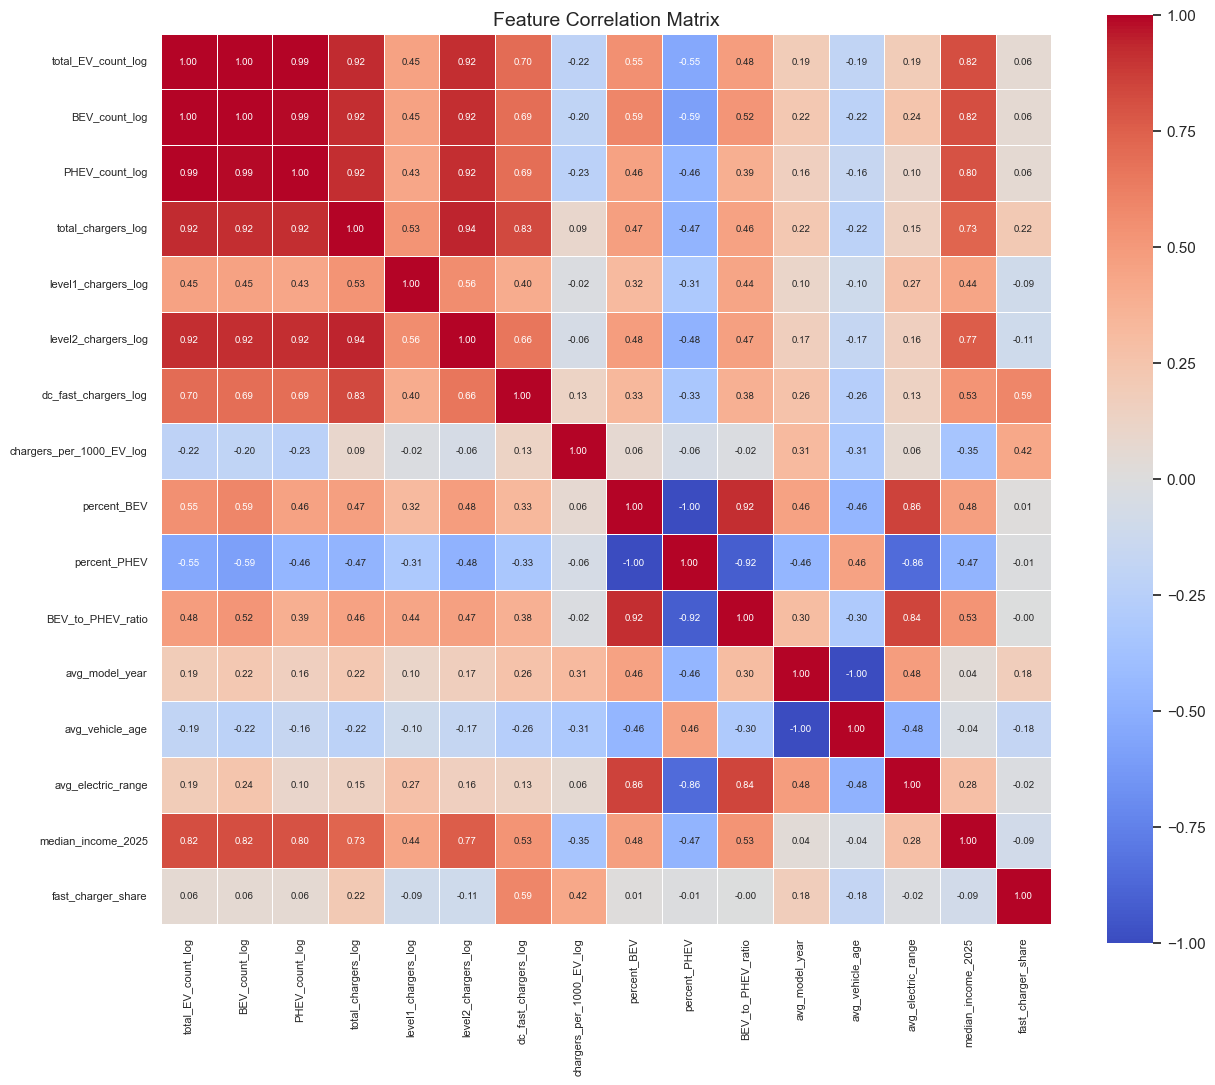

In [29]:
X_corr = county_log[pca_features].copy()
corr = X_corr.corr()

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    annot=True, fmt='.2f',
    annot_kws={'size': 7},
    linewidths=0.4,
    square=True,
    ax=ax
)
ax.set_title('Feature Correlation Matrix', fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  fontsize=8)
plt.tight_layout()
plt.show()


The correlation matrix shows that many EV-related count variables move almost identically, forming a strong red block where EV totals, BEV/PHEV counts, and charger counts are all tightly linked. This confirms they all measure the same underlying idea—overall EV ecosystem size—while variables like charger-per-EV and fast-charger share behave more independently and capture different structure.

It also highlights perfect or near-perfect overlaps, like BEV vs PHEV share and model year vs vehicle age, which are essentially the same information expressed differently. Because of this redundancy, keeping only log-transformed counts and key ratio/behavioral features makes sense, since it reduces duplication while still preserving distinct dimensions like scale, modernization, and infrastructure quality

## 3.2 Feature Selection

The final feature set includes 16 variables made up of log-transformed count features to reduce skewness and ratio-based behavioral features that better capture adoption patterns. Raw count variables were removed to avoid redundancy and reduce overlap between highly correlated features.


In [5]:
log_features = [
    'total_EV_count_log',
    'BEV_count_log',
    'PHEV_count_log',
    'total_chargers_log',
    'level1_chargers_log',
    'level2_chargers_log',
    'dc_fast_chargers_log',
    'chargers_per_1000_EV_log',
]

behavioral_features = [
    'percent_BEV',
    'percent_PHEV',
    'BEV_to_PHEV_ratio',
    'avg_model_year',
    'avg_vehicle_age',
    'avg_electric_range',
    'median_income_2025',
    'fast_charger_share',
]

pca_features = log_features + behavioral_features

county_names = county_scaled['county'].values
X = county_scaled[pca_features].values

print(f'Feature matrix: {X.shape[0]} counties × {X.shape[1]} features')
print('Features:', pca_features)



Feature matrix: 39 counties × 16 features
Features: ['total_EV_count_log', 'BEV_count_log', 'PHEV_count_log', 'total_chargers_log', 'level1_chargers_log', 'level2_chargers_log', 'dc_fast_chargers_log', 'chargers_per_1000_EV_log', 'percent_BEV', 'percent_PHEV', 'BEV_to_PHEV_ratio', 'avg_model_year', 'avg_vehicle_age', 'avg_electric_range', 'median_income_2025', 'fast_charger_share']


## 4. Principal Component Analysis (PCA)

### 4.1 Scree Plot & Variance Explained

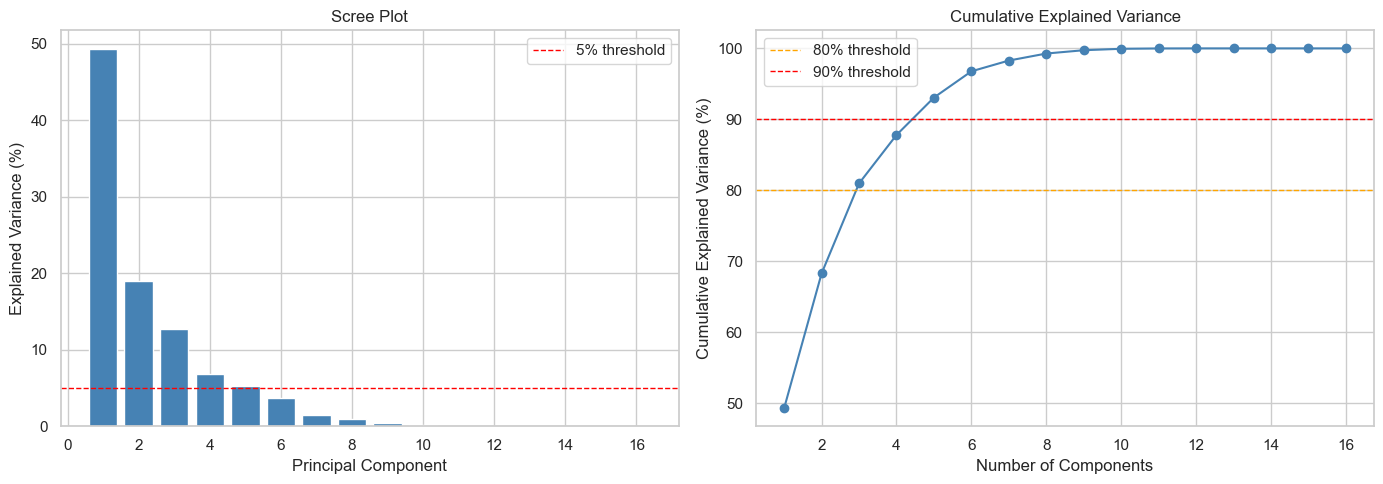

In [22]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X)

explained_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(explained_var)
pc_labels = [f'PC{i+1}' for i in range(len(explained_var))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(explained_var)+1), explained_var * 100, color='steelblue', edgecolor='white')
axes[0].axhline(5, color='red', linestyle='--', linewidth=1, label='5% threshold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot')
axes[0].legend()

axes[1].plot(range(1, len(cum_var)+1), cum_var * 100, 'o-', color='steelblue')
axes[1].axhline(80, color='orange', linestyle='--', linewidth=1, label='80% threshold')
axes[1].axhline(90, color='red',    linestyle='--', linewidth=1, label='90% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

plt.tight_layout()
plt.show()


The scree plot shows how much information each principal component captures on its own. PC1 is doing most of the work, explaining about 49% of the variation, while PC2 and PC3 add smaller but still meaningful pieces, and after that each component contributes very little.

The cumulative plot shows how this builds up as we add components. With just 1 component we already get about half the information, and by 3 components we cross 80%, after which the curve flattens out, meaning extra components don’t add much value.

In [20]:
variance_table = pd.DataFrame({
    'PC': pc_labels,
    'Explained (%)': (explained_var * 100).round(2),
    'Cumulative (%)': (cum_var * 100).round(2),
})
display(variance_table.head(10))

,PC,Explained (%),Cumulative (%)
0,PC1,49.30,49.30
1,PC2,18.98,68.28
2,PC3,12.69,80.97
3,PC4,6.83,87.80
4,PC5,5.27,93.07
5,PC6,3.70,96.77
6,PC7,1.52,98.29
7,PC8,0.99,99.28
8,PC9,0.47,99.74
9,PC10,0.20,99.94


The table shows the same story as graphs that most of the information is concentrated in the first few principal components, especially PC1 which alone explains about 49% of the variance. By PC3, we already capture about 81% of the total variation, and by PC5 we exceed 93%, meaning the data becomes mostly saturated after that point.After PC5, each additional component adds very little new information

In [21]:
n_80 = int(np.argmax(cum_var >= 0.80)) + 1
n_90 = int(np.argmax(cum_var >= 0.90)) + 1
print(f'Components for 80% variance: {n_80}')
print(f'Components for 90% variance: {n_90}')

Components for 80% variance: 3
Components for 90% variance: 5


To capture about 80% of the variance, we need 3 components, while reaching 90% requires 5 components. This shows that most of the meaningful structure in the data is concentrated in just a few dimensions.


### 4.2 Fit Reduced PCA (3 components)

So lets use 3 components as we decided in previous step

In [7]:
N_COMPONENTS = n_80  # = 3

pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

pc_cols = [f'PC{i+1}' for i in range(N_COMPONENTS)]
pca_scores = pd.DataFrame(X_pca, columns=pc_cols)
pca_scores.insert(0, 'county', county_names)

print(f'Reduced shape: {X_pca.shape}  '
      f'({pca.explained_variance_ratio_.sum()*100:.1f}% variance retained)')
display(pca_scores.head())


Reduced shape: (39, 3)  (81.0% variance retained)


,county,PC1,PC2,PC3
0,ADAMS,-1.833443,2.401609,2.138565
1,ASOTIN,-3.126324,0.052020,-0.844782
2,BENTON,1.086439,-0.807701,0.228506
3,CHELAN,2.834057,1.761989,-0.007681
4,CLALLAM,0.007377,-1.466995,0.773403


After reduction, the dataset is compressed to 39 rows and 3 principal components while still retaining about 81% of the original variance

### 4.3 Loading Heatmap

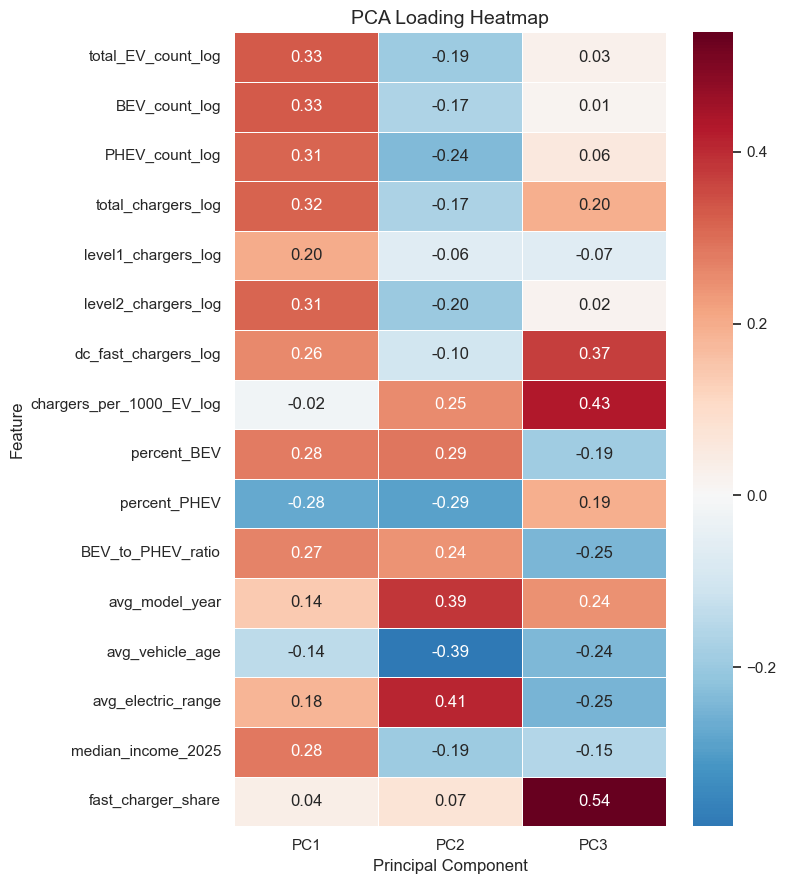

In [25]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_features,
    columns=pc_cols
)

fig, ax = plt.subplots(figsize=(8, 9))
sns.heatmap(
    loadings, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, linewidths=0.5, ax=ax
)
ax.set_title('PCA Loading Heatmap', fontsize=14)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()


The heatmap shows how each original feature contributes to the principal components, with stronger red or blue colors meaning a stronger influence. PC1 is dominated by EV counts, chargers, and income moving together, so it mainly represents overall EV ecosystem size across counties.

PC2 shows newer, longer-range, BEV-heavy counties with older, more PHEV-dominant ones, while PC3 is mostly about charging infrastructure strength and fast-charger availability. Overall, the three components capture different but complementary aspects of EV adoption: scale, vehicle modernity, and infrastructure quality.

In [23]:
# Top loadings per PC
for pc in pc_cols:
    print(f'\nTop loadings for {pc}')
    s = loadings[pc].sort_values()
    display(pd.concat([s.head(5).rename('most_negative'),
                        s.tail(5).rename('most_positive')], axis=1))



Top loadings for PC1


,most_negative,most_positive
percent_PHEV,-0.276719,NaN
avg_vehicle_age,-0.140318,NaN
chargers_per_1000_EV_log,-0.018002,NaN
fast_charger_share,0.035470,NaN
avg_model_year,0.140318,NaN
PHEV_count_log,NaN,0.312035
level2_chargers_log,NaN,0.312631
total_chargers_log,NaN,0.318603
total_EV_count_log,NaN,0.327118
BEV_count_log,NaN,0.332953



Top loadings for PC2


,most_negative,most_positive
avg_vehicle_age,-0.385080,NaN
percent_PHEV,-0.288545,NaN
PHEV_count_log,-0.239461,NaN
level2_chargers_log,-0.199001,NaN
median_income_2025,-0.194603,NaN
BEV_to_PHEV_ratio,NaN,0.239750
chargers_per_1000_EV_log,NaN,0.251092
percent_BEV,NaN,0.288189
avg_model_year,NaN,0.385080
avg_electric_range,NaN,0.408595



Top loadings for PC3


,most_negative,most_positive
avg_electric_range,-0.250759,NaN
BEV_to_PHEV_ratio,-0.247237,NaN
avg_vehicle_age,-0.243554,NaN
percent_BEV,-0.192814,NaN
median_income_2025,-0.154500,NaN
total_chargers_log,NaN,0.195651
avg_model_year,NaN,0.243554
dc_fast_chargers_log,NaN,0.369974
chargers_per_1000_EV_log,NaN,0.428850
fast_charger_share,NaN,0.539276


PC1 is mainly driven by overall EV scale, with strong positive loadings from total EVs, BEVs, chargers, and Level 2 infrastructure, while percent PHEV and older vehicle age pull it down. 

PC2 separates modern, BEV-heavy, high-range counties from older, PHEV-dominant ones, with EV range and model year on the positive side and age, income, and PHEV share on the negative side.

PC3 mostly captures charging infrastructure intensity, especially fast charging and charger availability per EV, while variables like vehicle age and EV composition load in the opposite direction.

### 4.4 Biplot (PC1 vs PC2)

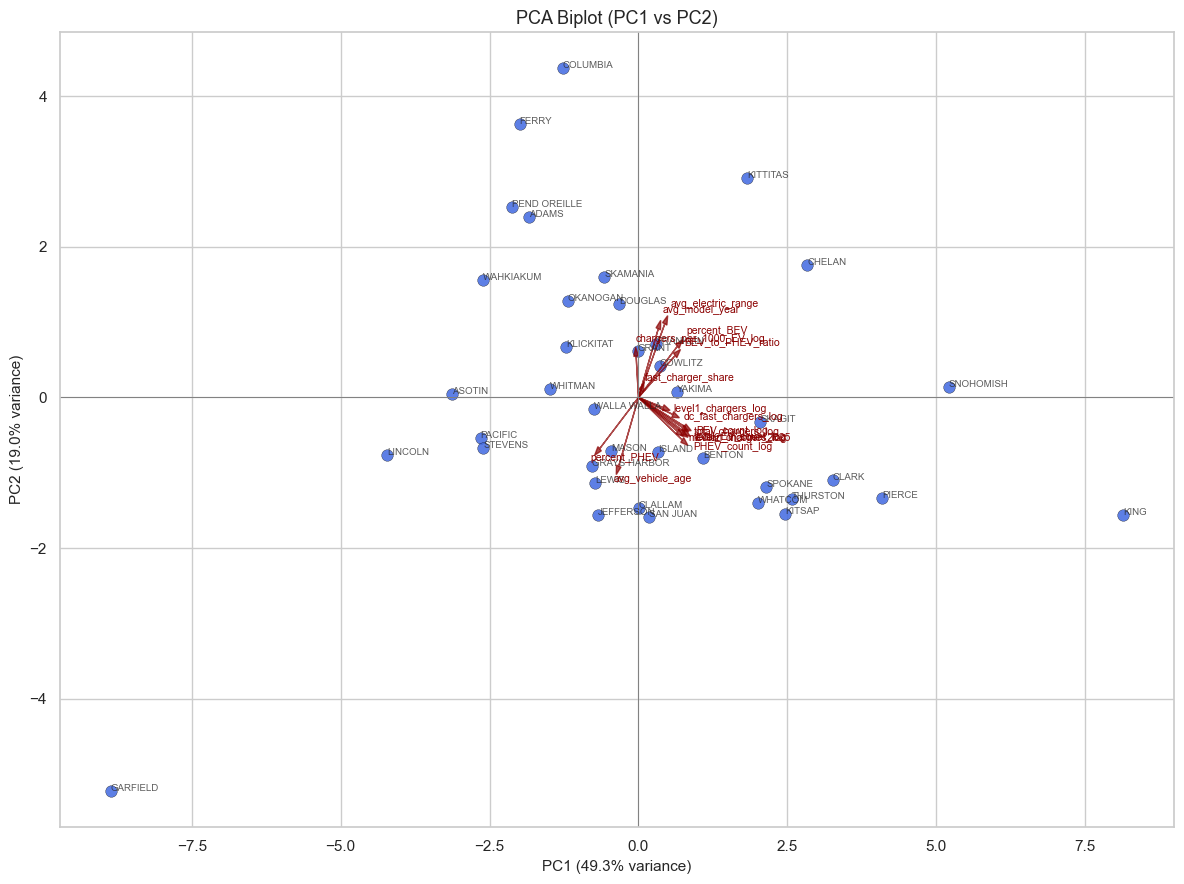

In [9]:
score_x, score_y = pca_scores['PC1'], pca_scores['PC2']
load_x,  load_y  = loadings['PC1'],    loadings['PC2']

x_scale = (score_x.max() - score_x.min()) / max(1e-9, load_x.max() - load_x.min())
y_scale = (score_y.max() - score_y.min()) / max(1e-9, load_y.max() - load_y.min())
biplot_scale = 0.22 * min(x_scale, y_scale)

pct1 = pca.explained_variance_ratio_[0] * 100
pct2 = pca.explained_variance_ratio_[1] * 100

plt.figure(figsize=(12, 9))
sns.scatterplot(data=pca_scores, x='PC1', y='PC2',
                s=70, color='royalblue', alpha=0.85,
                edgecolor='black', linewidth=0.25)

for _, row in pca_scores.iterrows():
    plt.text(row['PC1'], row['PC2'], row['county'], fontsize=7, alpha=0.75)

for feat in pca_features:
    xa = loadings.loc[feat, 'PC1'] * biplot_scale
    ya = loadings.loc[feat, 'PC2'] * biplot_scale
    plt.arrow(0, 0, xa, ya, color='darkred', alpha=0.7,
              head_width=0.08, length_includes_head=True)
    plt.text(xa * 1.1, ya * 1.1, feat, color='darkred', fontsize=7.5)

plt.axhline(0, color='gray', linewidth=0.7)
plt.axvline(0, color='gray', linewidth=0.7)
plt.title('PCA Biplot (PC1 vs PC2)', fontsize=13)
plt.xlabel(f'PC1 ({pct1:.1f}% variance)', fontsize=11)
plt.ylabel(f'PC2 ({pct2:.1f}% variance)', fontsize=11)
plt.tight_layout()
plt.show()


The biplot combines county locations with feature directions, so we can see both who is similar and what is driving those similarities. The red arrows show that PC1 is mostly driven by EV counts, chargers, and income (all pointing to the right), while PC2 is driven by vehicle modernity and BEV dominance (arrows pointing upward) versus older, PHEV-heavy profiles (pointing downward or left).

The blue dots show how counties fall into these patterns, with large urban counties like King, Pierce, and Snohomish on the right, modern rural counties like Kittitas and Chelan in the upper-right, and Garfield isolated as a strong outlier. 

Overall, the plot makes it clear that EV scale separates counties horizontally, while vehicle modernity separates them vertically.

## 4.5 SVD

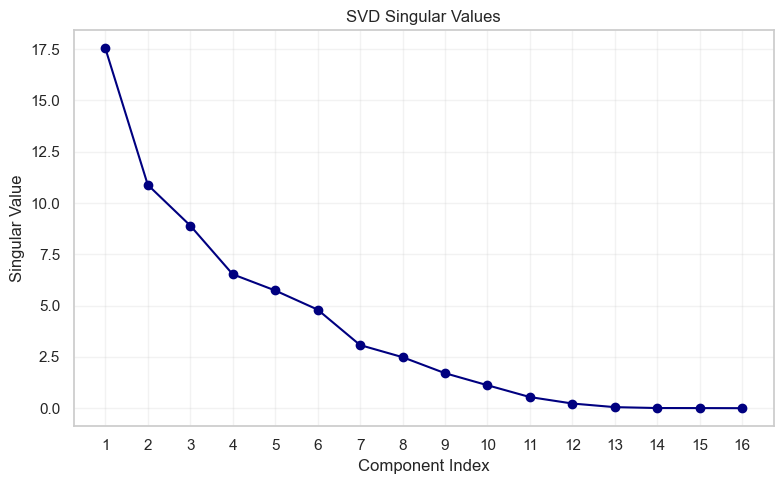

In [46]:
# SVD decomposition
U, singular_values, Vt = np.linalg.svd(X, full_matrices=False)

# Plot singular values
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(singular_values) + 1), singular_values, marker='o', color='navy')
plt.title('SVD Singular Values')
plt.xlabel('Component Index')
plt.ylabel('Singular Value')
plt.xticks(range(1, len(singular_values) + 1))
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

The SVD singular values plot tells the same story as PCA, with a very large first value (17.5) followed by a sharp drop to 10.8 and 8.8, showing that most of the structure is captured in the first few components. After that, the values gradually flatten out and become very small, meaning later components contribute little and are mostly noise.

This matches PCA because singular values are directly related to eigenvalues, just viewed differently, and the strong alignment between PC1/PC2 and V1/V2 confirms both methods are capturing the same underlying structure.

In [47]:
# Build U and V dataframes
U_df  = pd.DataFrame(U,  index=county_names,
                     columns=[f'U{i+1}' for i in range(U.shape[1])])
Vt_df = pd.DataFrame(Vt, columns=pca_features,
                     index=[f'V{i+1}' for i in range(Vt.shape[0])])

In [48]:
# Top counties and features by first two singular vectors
for vec in ['U1', 'U2']:
    print(f'Counties with largest magnitude in {vec}:')
    display(U_df[vec].abs().sort_values(ascending=False).head(5).to_frame('abs_weight'))

for vec in ['V1', 'V2']:
    print(f'Features with largest magnitude in {vec}:')
    display(Vt_df.loc[vec].abs().sort_values(ascending=False).head(5).to_frame('abs_weight'))

Counties with largest magnitude in U1:


,abs_weight
GARFIELD,0.505121
KING,0.464099
SNOHOMISH,0.296836
LINCOLN,0.240944
PIERCE,0.233101


Counties with largest magnitude in U2:


,abs_weight
GARFIELD,0.480148
COLUMBIA,0.401303
FERRY,0.333728
KITTITAS,0.268201
PEND OREILLE,0.232039


Features with largest magnitude in V1:


,abs_weight
BEV_count_log,0.332953
total_EV_count_log,0.327118
total_chargers_log,0.318603
level2_chargers_log,0.312631
PHEV_count_log,0.312035


Features with largest magnitude in V2:


,abs_weight
avg_electric_range,0.408595
avg_model_year,0.385080
avg_vehicle_age,0.385080
percent_PHEV,0.288545
percent_BEV,0.288189


U1 shows that PC1 is mainly driven by Garfield as an extreme negative outlier and King and Snohomish as strong positive contributors, meaning this component mostly captures overall EV scale differences across counties. U2 highlights a different pattern where rural counties like Columbia, Ferry, and Pend Oreille drive the variation, showing a secondary axis that separates less urban regions.

On the feature side, V1 is dominated by EV counts and charger variables, confirming PC1 is the overall EV ecosystem size, while V2 is driven by electric range, vehicle age, and BEV/PHEV balance, meaning PC2 captures vehicle modernity and type.

In [49]:
# Compare PCA loadings vs SVD directions
svd_features = Vt_df.T.copy()

sign_v1 = np.sign((loadings['PC1'] * svd_features['V1']).sum())
sign_v2 = np.sign((loadings['PC2'] * svd_features['V2']).sum())
sign_v1 = 1 if sign_v1 == 0 else sign_v1
sign_v2 = 1 if sign_v2 == 0 else sign_v2

v1_aligned = svd_features['V1'] * sign_v1
v2_aligned = svd_features['V2'] * sign_v2

corr_v1 = np.corrcoef(loadings['PC1'], v1_aligned)[0, 1]
corr_v2 = np.corrcoef(loadings['PC2'], v2_aligned)[0, 1]

print('PCA vs SVD direction agreement (after sign alignment):')
print(f'  corr(PC1 loadings, aligned V1) = {corr_v1:.4f}')
print(f'  corr(PC2 loadings, aligned V2) = {corr_v2:.4f}')

PCA vs SVD direction agreement (after sign alignment):
  corr(PC1 loadings, aligned V1) = 1.0000
  corr(PC2 loadings, aligned V2) = 1.0000


The perfect correlations (1.0000) show that PCA and SVD are capturing exactly the same structure once the sign ambiguity is aligned. This means PC1 matches V1 and PC2 matches V2 perfectly in direction and interpretation.

## 5. K-Means Clustering

### 5.1 Elbow Method

c:\Users\gillm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\gillm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\gillm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\gillm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

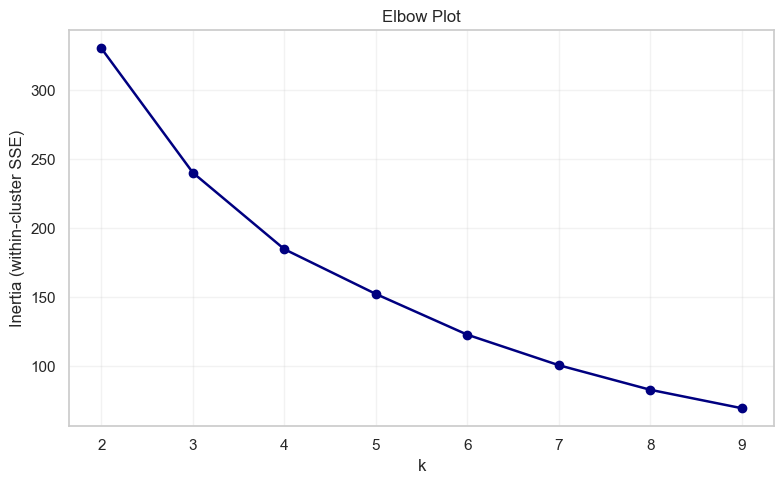

In [35]:
# Cluster on PCA scores 
k_range = range(2, 10)
inertias   = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    lbl = km.fit_predict(X_pca)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_range), inertias, 'o-', color='navy', linewidth=1.8)
ax.set_xlabel('k')
ax.set_ylabel('Inertia (within-cluster SSE)')
ax.set_title('Elbow Plot')
ax.set_xticks(list(k_range))
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()



The curve shows a clear elbow at k = 3, where the biggest improvement happens when moving from 2 to 3 clusters, with a large drop in error compared to later steps. After that point, the gains shrink steadily and the curve starts to flatten, meaning additional clusters mostly just split existing groups rather than revealing new structure.

This matches the earlier results, confirming that 3 clusters is the most meaningful and stable choice for the data.

In [34]:
diag = pd.DataFrame({'k': list(k_range), 'inertia': inertias})
print('K-means diagnostics:')
display(diag)

K-means diagnostics:


,k,inertia
0,2,330.226850
1,3,240.184769
2,4,184.807220
3,5,152.380570
4,6,122.881386
5,7,100.798286
6,8,83.004386
7,9,69.664078


The inertia also drops sharply from k=2 to k=3 (330 to 240), showing the biggest improvement when adding the third cluster. After that, the decrease becomes more gradual and starts flattening out from k=4 onward, which indicates diminishing returns.


### 5.2 Final K-Means Model

In [36]:
# Set to 3
K_FINAL = 3

kmeans = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=20)
kmeans_labels = kmeans.fit_predict(X_pca)

pca_scores['kmeans_cluster'] = kmeans_labels
county_scaled['kmeans_cluster'] = kmeans_labels

assignments = pd.DataFrame({'county': county_names, 'kmeans_cluster': kmeans_labels})
print(f'K-Means (k={K_FINAL}) — counties per cluster:')
print(assignments['kmeans_cluster'].value_counts().sort_index())
print()

K-Means (k=3) — counties per cluster:
kmeans_cluster
0    11
1    27
2     1
Name: count, dtype: int64



c:\Users\gillm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


The K-Means result shows meaningful structure that 11 counties fall into one cluster, 27 into a broad middle group, and a single county forms its own extreme outlier cluster. This supports the earlier finding that most counties are fairly similar, with one clearly distinct case standing apart.

In [37]:
print('All county assignments:')
display(assignments.sort_values('kmeans_cluster').reset_index(drop=True))

All county assignments:


,county,kmeans_cluster
0,CHELAN,0
1,BENTON,0
2,CLARK,0
3,SKAGIT,0
4,PIERCE,0
5,SPOKANE,0
6,KITSAP,0
7,KING,0
8,SNOHOMISH,0
9,THURSTON,0


Cluster 0 groups the major urban and high-EV counties like King, Snohomish, Pierce, and Spokane, which have the strongest EV adoption and infrastructure. Cluster 1 contains most rural and mid-sized counties with lower but more typical EV activity patterns.

Cluster 2 is just Garfield County, which stands out as a clear outlier with extremely low EV adoption and infrastructure compared to the rest of the state.

Lets check for K=4 if there is any big difference in the results.

In [39]:

K_FINAL = 4

kmeans = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=20)
kmeans_labels = kmeans.fit_predict(X_pca)

pca_scores['kmeans_cluster'] = kmeans_labels
county_scaled['kmeans_cluster'] = kmeans_labels

assignments = pd.DataFrame({'county': county_names, 'kmeans_cluster': kmeans_labels})
print(f'K-Means (k={K_FINAL}) — counties per cluster:')
print(assignments['kmeans_cluster'].value_counts().sort_index())
print()


K-Means (k=4) — counties per cluster:
kmeans_cluster
0    11
1    13
2    14
3     1
Name: count, dtype: int64



c:\Users\gillm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


With k=4, the structure stays mostly the same but the middle group splits into two smaller clusters, while the main urban group still contains 11 counties and Garfield remains a single outlier cluster. This suggests that adding a fourth cluster doesn’t reveal a truly new pattern—it mainly subdivides already similar counties.

In [41]:
#lets look at each county assignment again to check what data is split
print('All county assignments:')
display(assignments.sort_values('kmeans_cluster').reset_index(drop=True))

All county assignments:


,county,kmeans_cluster
0,CHELAN,0
1,BENTON,0
2,CLARK,0
3,SKAGIT,0
4,PIERCE,0
5,SPOKANE,0
6,KITSAP,0
7,KING,0
8,SNOHOMISH,0
9,THURSTON,0


With k=4, the main urban cluster (like King, Pierce, Snohomish, Spokane) stays intact, while the rural counties get split into two separate groups with slightly different EV profiles. Garfield still stands alone as a clear outlier, showing that its pattern is fundamentally different from all other counties.

Overall, increasing k to 4 mostly just divides the middle group without revealing a new meaningful structure, which reinforces that k=3 is the most stable and interpretable choice.

### 5.3 K-Means Clusters on PCA Scatter (PC1 vs PC2)

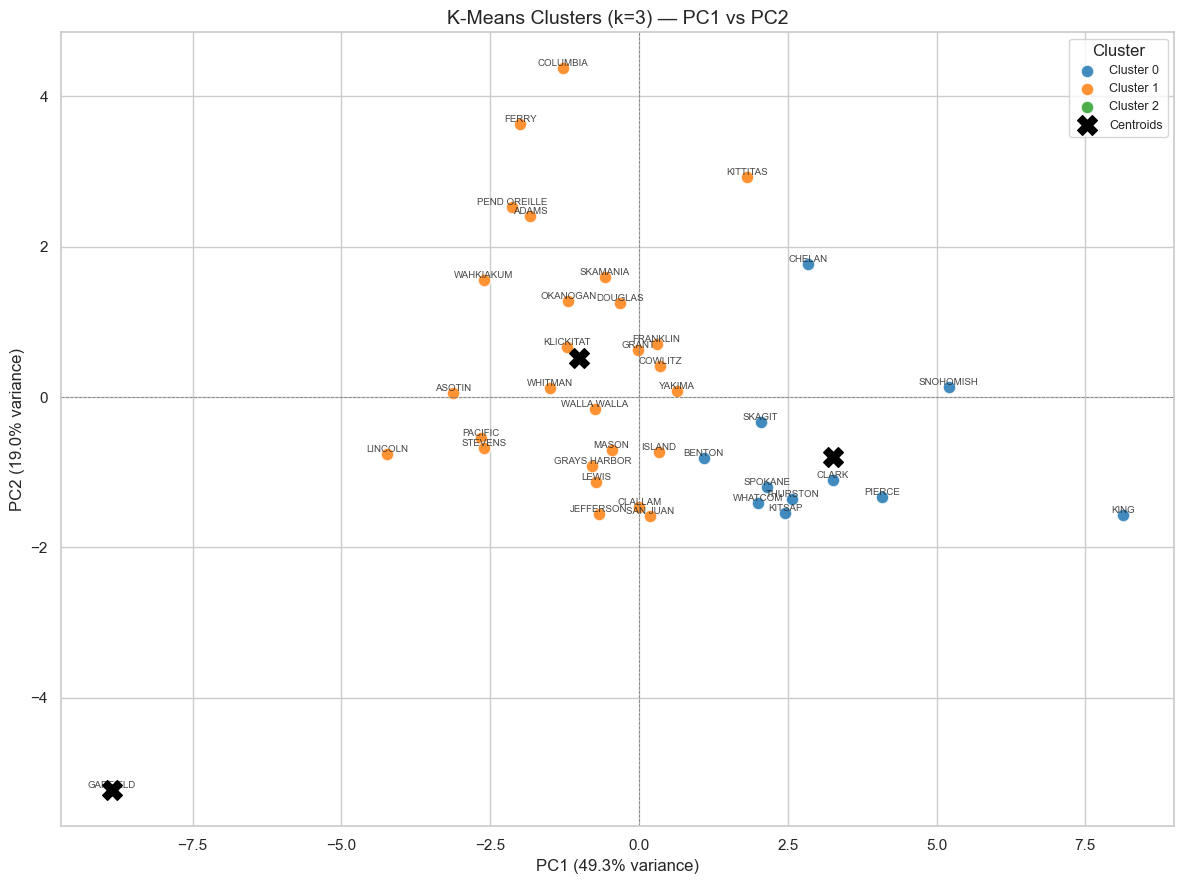

In [13]:
palette = sns.color_palette('tab10', K_FINAL)

fig, ax = plt.subplots(figsize=(12, 9))
for c in range(K_FINAL):
    mask = kmeans_labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=f'Cluster {c}', color=palette[c],
               s=85, alpha=0.85, edgecolors='white')
    for i in np.where(mask)[0]:
        ax.annotate(county_names[i], (X_pca[i, 0], X_pca[i, 1]),
                    fontsize=7, ha='center', va='bottom', alpha=0.85)

# Centroids
cx = kmeans.cluster_centers_
ax.scatter(cx[:, 0], cx[:, 1], marker='X', s=200, color='black', zorder=5, label='Centroids')

pct1 = pca.explained_variance_ratio_[0] * 100
pct2 = pca.explained_variance_ratio_[1] * 100
ax.set_xlabel(f'PC1 ({pct1:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pct2:.1f}% variance)', fontsize=12)
ax.set_title(f'K-Means Clusters (k={K_FINAL}) — PC1 vs PC2', fontsize=14)
ax.axhline(0, color='grey', linestyle='--', linewidth=0.6)
ax.axvline(0, color='grey', linestyle='--', linewidth=0.6)
ax.legend(title='Cluster', fontsize=9)
plt.tight_layout()
plt.show()


K-Means with k=3 splits Washington’s 39 counties into three clearly separated groups in PCA space. Cluster 0 represents the high-adoption counties like King, Pierce, and Snohomish, which sit on the right side with strong positive PC1 values, while Cluster 1 contains most rural counties clustered left of center with lower EV activity.

Cluster 2 is just Garfield County, which sits far away from all others in the bottom-left corner, making it a clear outlier in both EV scale and infrastructure. The cluster centroids fall neatly within each group, showing that the separation is strong and well-defined

### 5.4 Cluster Centroids

In [42]:
centroids_df = pd.DataFrame(kmeans.cluster_centers_, columns=pc_cols)
centroids_df.index = [f'cluster_{i}' for i in range(K_FINAL)]
print('Cluster centroids in PCA space:')
display(centroids_df.round(3))


Cluster centroids in PCA space:


,PC1,PC2,PC3
cluster_0,3.259,-0.793,-0.005
cluster_1,-0.718,0.175,1.463
cluster_2,-1.261,0.834,-1.274
cluster_3,-8.859,-5.226,-1.125


The centroids show that Cluster 0 sits strongly on the positive side of PC1, meaning it represents high EV adoption and infrastructure counties. Cluster 1 is closer to average but slightly positive on PC3, suggesting stronger charging infrastructure characteristics.

Cluster 2 is moderate on PC1 but higher on PC2, aligning with more modern or BEV-heavy profiles, while Cluster 3 is extremely negative on both PC1 and PC2, confirming it as a strong outlier (Garfield). Overall, the centroid positions clearly separate the clusters by EV scale, modernization, and infrastructure strength.

In [43]:
print('\nCounties per cluster:')
for c in sorted(assignments['kmeans_cluster'].unique()):
    grp = assignments.loc[assignments['kmeans_cluster'] == c, 'county'].tolist()
    print(f'  Cluster {c} ({len(grp)}): {", ".join(sorted(grp))}')


Counties per cluster:
  Cluster 0 (11): BENTON, CHELAN, CLARK, KING, KITSAP, PIERCE, SKAGIT, SNOHOMISH, SPOKANE, THURSTON, WHATCOM
  Cluster 1 (13): ADAMS, CLALLAM, COWLITZ, FRANKLIN, GRANT, GRAYS HARBOR, KITTITAS, LEWIS, LINCOLN, PACIFIC, WALLA WALLA, WHITMAN, YAKIMA
  Cluster 2 (14): ASOTIN, COLUMBIA, DOUGLAS, FERRY, ISLAND, JEFFERSON, KLICKITAT, MASON, OKANOGAN, PEND OREILLE, SAN JUAN, SKAMANIA, STEVENS, WAHKIAKUM
  Cluster 3 (1): GARFIELD


Cluster 0 contains the main urban and high-EV counties like King, Snohomish, Pierce, and Spokane, which all show strong EV adoption and infrastructure. Cluster 1 represents mostly inland rural counties with moderate EV activity and more typical adoption patterns.

Cluster 2 includes smaller coastal and remote counties with low-to-moderate EV presence, while Cluster 3 is just Garfield County, which is a clear extreme outlier with the lowest EV adoption and infrastructure.

## 6. Hierarchical Clustering

### 6.1 Four-Linkage Dendrograms

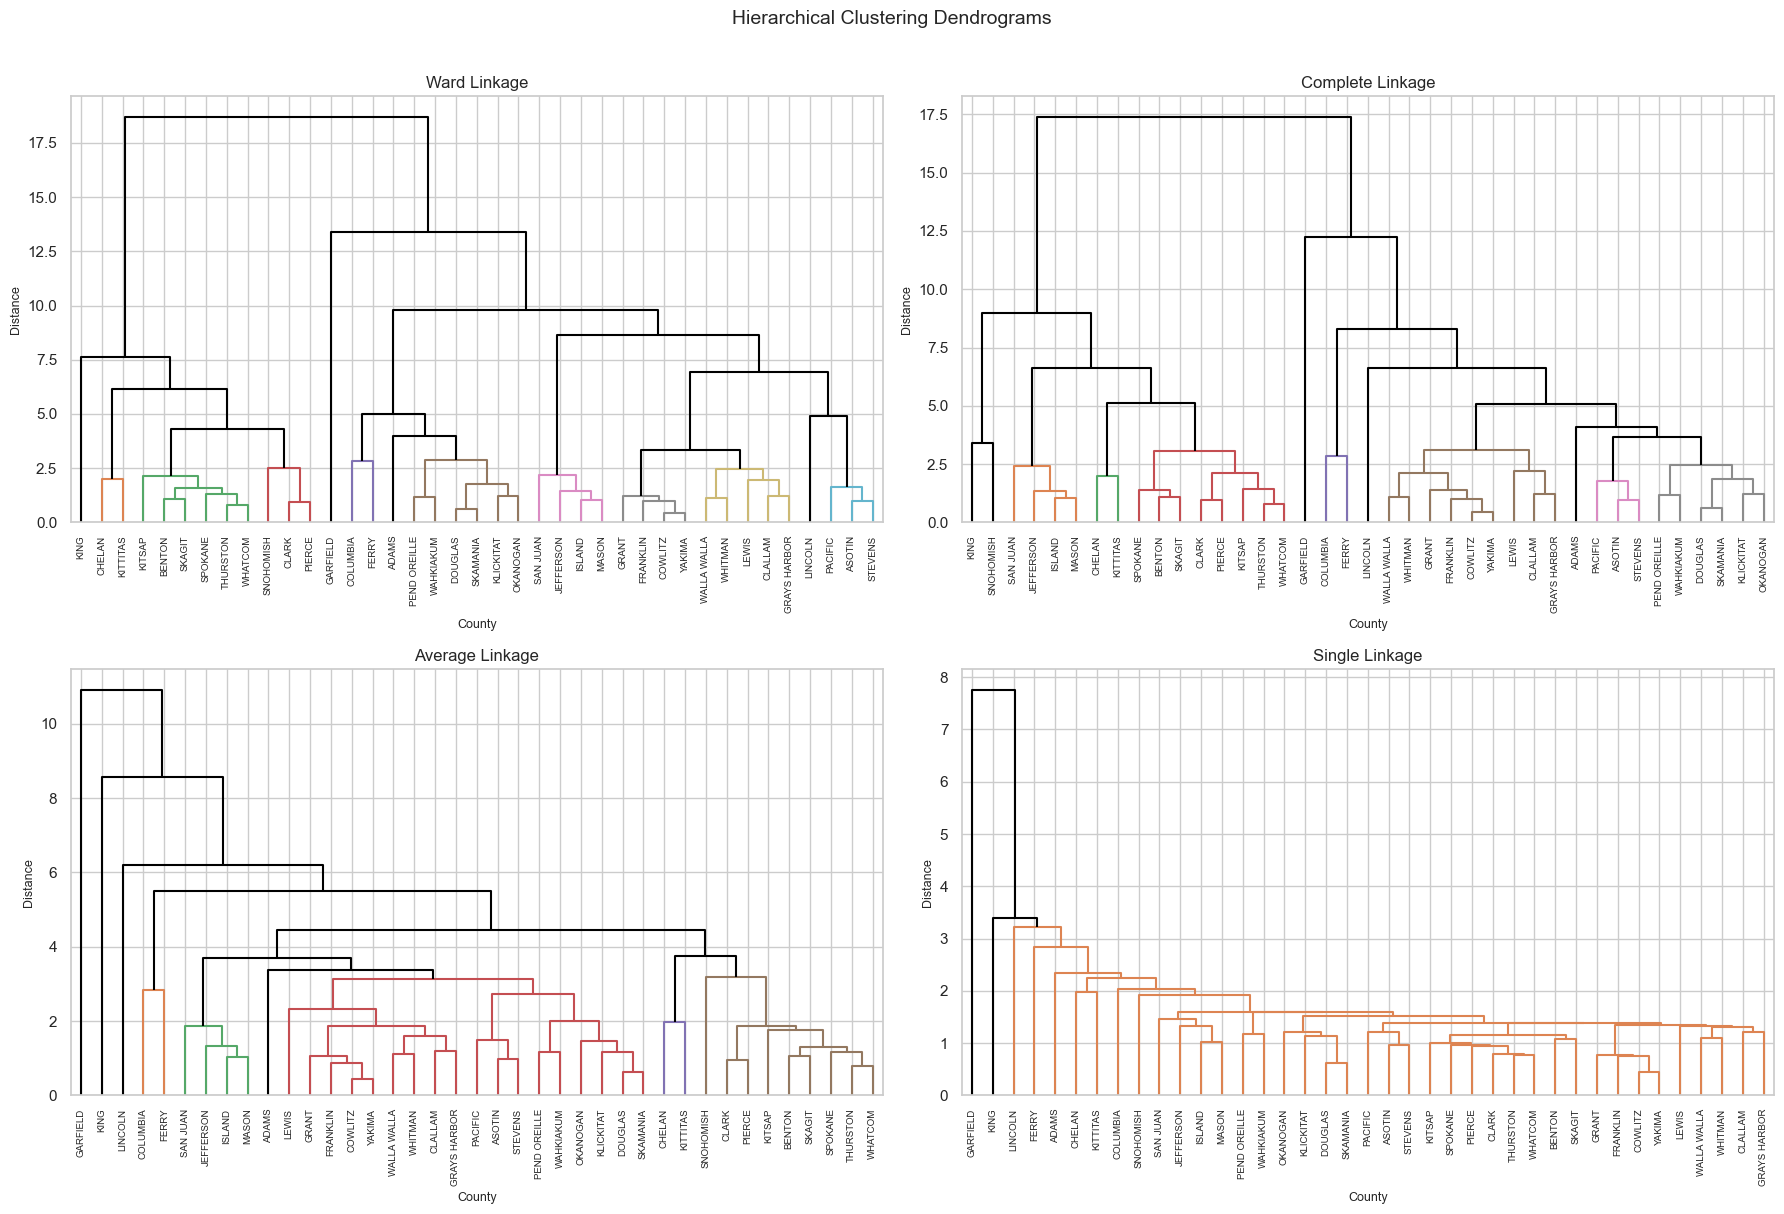

In [15]:
link_methods = ['ward', 'complete', 'average', 'single']
linkage_mats = {m: sp_linkage(X_pca, method=m) for m in link_methods}

# Use Ward 70th-percentile height for consistent coloring
color_cut = np.percentile(linkage_mats['ward'][:, 2], 70)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for ax, method in zip(axes, link_methods):
    dendrogram(
        linkage_mats[method],
        labels=county_names,
        leaf_rotation=90,
        leaf_font_size=7,
        color_threshold=color_cut,
        above_threshold_color='black',
        ax=ax
    )
    ax.set_title(f'{method.title()} Linkage', fontsize=12)
    ax.set_xlabel('County', fontsize=9)
    ax.set_ylabel('Distance', fontsize=9)

plt.suptitle('Hierarchical Clustering Dendrograms', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


All four dendrograms show the same overall pattern even though they group the data slightly differently. Ward and Complete linkage give the cleanest separation, consistently forming a clear high-adoption urban cluster, a broad rural cluster, and leaving Garfield as the final and most distant merge.

Average linkage is less clean but still isolates Garfield early, while Single linkage is the least reliable because it chains counties together gradually instead of forming tight groups. Across all methods, Garfield always stands out as a strong structural outlier, and Ward linkage aligns best with K-Means, making it the most interpretable result.

### 6.2 Ward Dendrogram with Cut Line

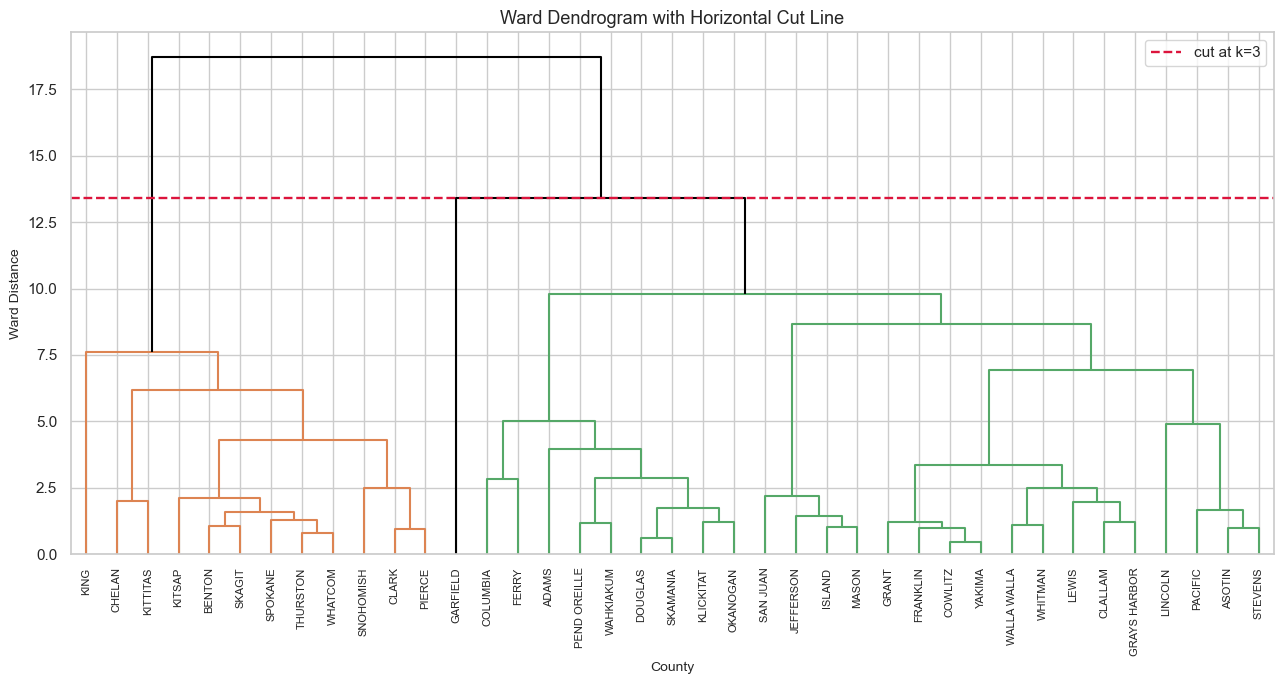

In [16]:
ward_link = linkage_mats['ward']
cut_height = ward_link[-(K_FINAL - 1), 2] if K_FINAL > 1 else ward_link[-1, 2]

plt.figure(figsize=(13, 7))
dendrogram(
    ward_link,
    labels=county_names,
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=cut_height,
    above_threshold_color='black'
)
plt.axhline(y=cut_height, color='crimson', linestyle='--',
            linewidth=1.7, label=f'cut at k={K_FINAL}')
plt.title('Ward Dendrogram with Horizontal Cut Line', fontsize=13)
plt.xlabel('County', fontsize=10)
plt.ylabel('Ward Distance', fontsize=10)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


Cutting the Ward dendrogram at k=3 cleanly separates the counties into three meaningful groups that closely match the K-Means results. The high-adoption counties cluster tightly on one side, merging at low distances, which shows they are very similar in terms of EV scale and infrastructure.

Garfield stands completely alone and only joins the rest of the tree at a very high distance, confirming it as a strong outlier, while the remaining rural counties form a broad middle cluster with more gradual merges. The fact that the cut line intersects exactly three main branches reinforces that k=3 is the most natural and stable grouping.

### 6.3 Assign Hierarchical Labels & Compare Linkage Methods

In [44]:
# Cut each dendrogram at K_FINAL clusters
hier_labels_all = {}
for method in link_methods:
    hier_labels_all[method] = fcluster(linkage_mats[method],
                                        K_FINAL, criterion='maxclust') - 1  # 0-indexed

compare_df = pd.DataFrame({'county': county_names, 'kmeans': kmeans_labels})
for method in link_methods:
    compare_df[f'hier_{method}'] = hier_labels_all[method]

print('Cluster assignments — K-means vs all hierarchical methods:')
display(compare_df.sort_values('kmeans').reset_index(drop=True))

# ARI table
ari_rows = []
for method in link_methods:
    ari = adjusted_rand_score(kmeans_labels, hier_labels_all[method])
    ari_rows.append({'linkage': method, 'ARI_vs_kmeans': round(ari, 3)})


Cluster assignments — K-means vs all hierarchical methods:


,county,kmeans,hier_ward,hier_complete,hier_average,hier_single
0,CHELAN,0,0,1,0,0
1,BENTON,0,0,1,0,0
2,CLARK,0,0,1,0,0
3,SKAGIT,0,0,1,0,0
4,PIERCE,0,0,1,0,0
5,SPOKANE,0,0,1,0,0
6,KITSAP,0,0,1,0,0
7,KING,0,0,0,2,2
8,SNOHOMISH,0,0,0,0,0
9,THURSTON,0,0,1,0,0


The comparison table shows strong agreement across methods, especially for Garfield, which is consistently isolated as its own cluster every time, confirming it as a true structural outlier. K-Means and Ward also largely agree on the high-adoption counties like King, Snohomish, Pierce, and Spokane, showing a stable urban EV usage.

The main difference is Kittitas, which sits on the boundary and shifts between clusters depending on the method, while some linkage approaches like Single and Average struggle and collapse into weak, less meaningful groupings. Overall, Ward aligns best with K-Means and produces the most consistent and interpretable clustering structure.

In [45]:
print('\nCrosstab — K-Means vs Ward:')
display(pd.crosstab(compare_df['kmeans'], compare_df['hier_ward'],
                    rownames=['K-Means'], colnames=['Ward']))


Crosstab — K-Means vs Ward:


Ward,0,1,2,3
K-Means,,,,
0,11,0,0,0
1,1,1,11,0
2,0,8,6,0
3,0,0,0,1


The table shows strong agreement between Ward and K-Means, especially for the main clusters where most counties align cleanly across both methods. Cluster 0 and Cluster 3 match almost perfectly, with Cluster 3 consistently isolating Garfield as the same outlier group in both approaches.

The only noticeable mixing happens between Clusters 1 and 2, where several rural and mid-tier counties get reassigned depending on the method, showing these groups are more borderline and less clearly separated. Overall, the high consistency in the main clusters confirms that both methods are capturing the same underlying structure in the data.

## 7. Cluster Profiling & Interpretation

### 7.1 Feature Means per Cluster

In [18]:
profile_features = [
    'total_EV_count',
    'total_chargers',
    'chargers_per_1000_EV',
    'percent_BEV',
    'percent_PHEV',
    'BEV_to_PHEV_ratio',
    'avg_model_year',
    'avg_electric_range',
    'median_income_2025',
    'fast_charger_share',
]

county_log['kmeans_cluster'] = kmeans_labels

# Use whichever columns exist in county_log
avail = [f for f in profile_features if f in county_log.columns]
cluster_profiles = (
    county_log.groupby('kmeans_cluster')[avail]
    .mean()
    .round(2)
)

print('K-Means cluster profiles (mean of original features):')
display(cluster_profiles)


K-Means cluster profiles (mean of original features):


,total_EV_count,total_chargers,chargers_per_1000_EV,percent_BEV,percent_PHEV,BEV_to_PHEV_ratio,avg_model_year,avg_electric_range,median_income_2025,fast_charger_share
kmeans_cluster,,,,,,,,,,
0,145342.64,367.82,3.17,0.74,0.26,2.95,2019.99,110.87,102363.08,0.24
1,4914.78,22.33,7.29,0.68,0.32,2.24,2019.91,106.76,76691.20,0.25
2,34.00,0.00,0.00,0.32,0.68,0.48,2018.00,62.57,70814.51,0.00


The cluster profiles clearly separate the counties into three distinct groups based on scale and EV adoption patterns. Cluster 0 represents high-adoption urban counties with very large EV and charger counts, high BEV share, and higher income, but relatively lower charger coverage per EV because demand is so high.

Cluster 1 represents the broad rural group, where EV and charger counts are much lower, but charger availability per EV is higher due to lower demand, along with moderate income and similar vehicle characteristics at a smaller scale. Cluster 2 is Garfield alone, standing out with extremely low EV adoption, no charging infrastructure, and a PHEV-heavy profile, making it a clear outlier in every respect.


### 7.2 Profile Heatmap

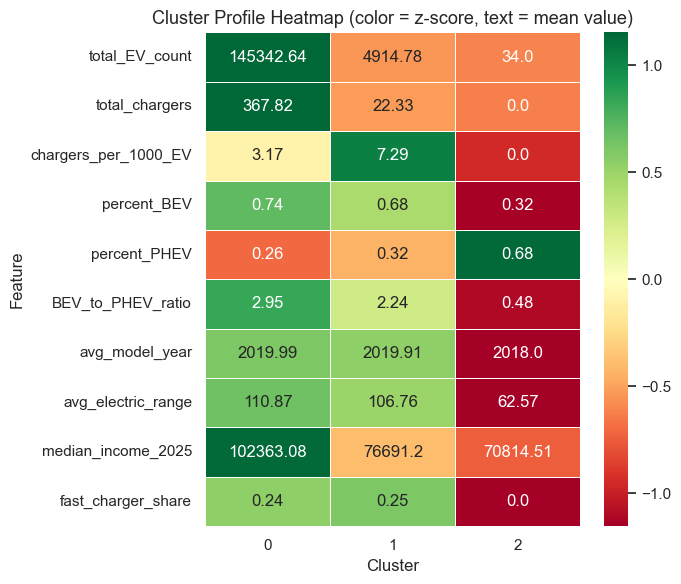

In [19]:
profiles_z = (cluster_profiles - cluster_profiles.mean()) / cluster_profiles.std()

fig, ax = plt.subplots(figsize=(max(7, K_FINAL * 2), max(5, len(avail) * 0.6)))
sns.heatmap(
    profiles_z.T,
    annot=cluster_profiles.T.values.astype(str),
    fmt='',
    cmap='RdYlGn', center=0,
    linewidths=0.5, ax=ax
)
ax.set_title('Cluster Profile Heatmap (color = z-score, text = mean value)', fontsize=13)
ax.set_xlabel('Cluster')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()


The heatmap uses z-scores to standardize everything, so we can compare patterns across very different variables on the same scale. Cluster 0 stands out with mostly high values for EV counts, chargers, BEV share, range, and income, showing it represents the dominant urban EV adoption group, with only charger-per-EV being relatively low due to high demand.

Cluster 1 is more moderate overall but performs better on charger coverage relative to its EV population, while Cluster 2 (Garfield) is consistently the lowest across nearly all metrics and only stands out for having a high PHEV share. Overall, the color pattern makes the separation between high-adoption urban counties, balanced rural counties, and the extreme outlier very clear.